In [33]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [34]:
FACTOR_MODELS = {
    "CAPM": ["Mkt-RF"],
    "F3F": ["Mkt-RF", "SMB", "HML"],
    "F5F": ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
}

In [35]:
def acess_factor(label, model_name):
    
    FF = pd.read_csv(f'../data/fatores_ff/ff_{label}.csv')
    FF["Date"] = pd.to_datetime(FF["Date"], format='%Y%m') + pd.offsets.MonthEnd(0)
    FF.set_index("Date", inplace=True)
    FF = FF / 100

    factors = FACTOR_MODELS.get(model_name)
    
    # O ideal é mapearmos os ativos de maneira que não ocorra nenhum tipo de erro, já que não estou fazendo nenhum tratamento no código. Estou incluindo essa parte apenas por precaução.
    if factors is None:
        return None
    
    FF = FF[factors + ["RF"]]

    return FF

In [36]:
def acess_data_etf(ticker_symbol, date_start, date_end):

    DATA_ETF = yf.download(
        tickers=ticker_symbol,
        start = pd.to_datetime(date_start) - pd.DateOffset(months=1),
        end = '2024-12-31',
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    if "Adj Close" not in DATA_ETF.columns:
        DATA_ETF["Adj Close"] = DATA_ETF["Close"]

    DATA_ETF = (
        DATA_ETF
            .resample("ME").last()[['Adj Close']]
            .pct_change()
            .dropna()
    )

    DATA_ETF.columns = ['adj_close']

    return DATA_ETF

In [37]:
def gera_grafico_ff(df, model):
    
    df['ff_excess_return'] = model.fittedvalues
    df['ff_total_return'] = df['ff_excess_return'] + df['RF']

    plt.figure(figsize=(12, 6))

    plt.plot(
        df.index,
        df['adj_close'],
        label='Retorno real',
        linewidth = 2.2
    )

    plt.plot(
        df.index,
        df['ff_total_return'],
        label='Retorno explicado',
        linestyle='--',
        linewidth = 2,
        alpha = 0.85
    )

    plt.axhline(0, linestyle=':', linewidth=1)

    plt.title(
        'Retorno mensal real vs explicado pelo modelo',
        fontsize=14
    )
    plt.xlabel('Data')
    plt.ylabel('Retorno mensal')

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()
    plt.show()


In [38]:
def french_fama(ticker_symbol, label, date_start, date_end, model_name):
    FF = acess_factor(label, model_name)
    DATA_ETF = acess_data_etf(ticker_symbol, date_start, date_end)
    
    DATA = DATA_ETF.merge(FF, how='left', left_index=True, right_index=True)
    DATA['excess_return'] = DATA['adj_close'] - DATA['RF']

    col_factors = [i for i in DATA.columns if i not in ("RF", "adj_close", "excess_return")]

    Y = DATA['excess_return']
    X = DATA[col_factors]
    model = sm.OLS(Y, X).fit()

    r2 =  model.rsquared
    mse = model.mse_resid

    betas = model.params
    factor_means = DATA[col_factors].mean()
    rf_mean = DATA['RF'].mean()

    E_return = rf_mean + betas @ factor_means
    E_return_annual = (1 + E_return) ** 12 - 1

    gera_grafico_ff(DATA, model)

    return (E_return_annual * 100, r2 * 100, mse * 100, model)

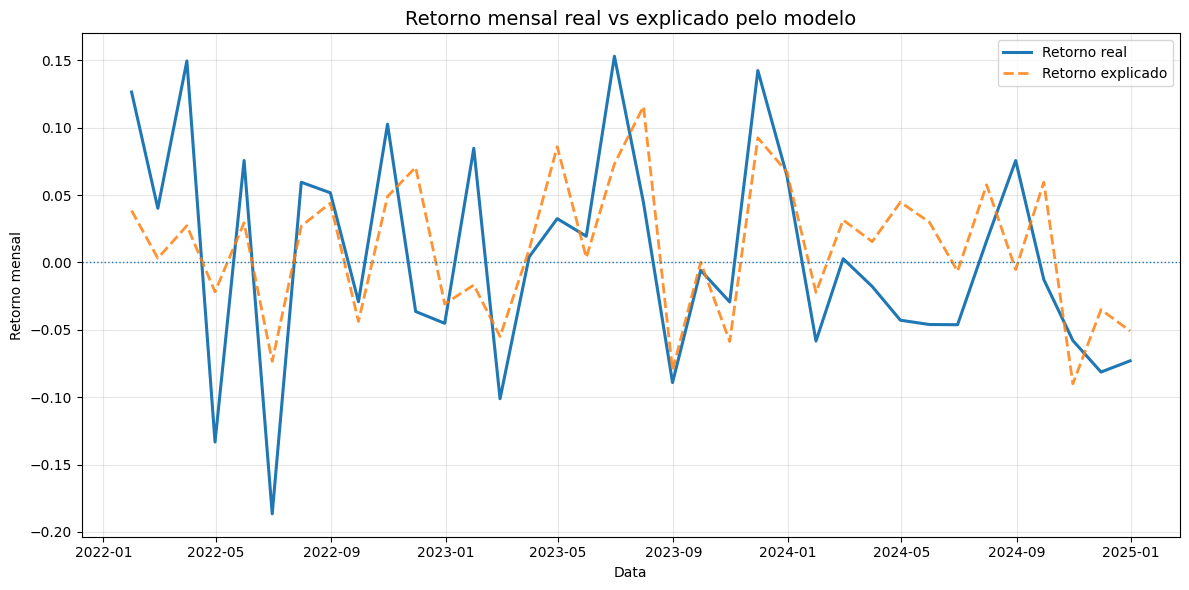

(np.float64(13.604286346300132), np.float64(41.740265892111886), np.float64(0.42983736756481494))
                                 OLS Regression Results                                
Dep. Variable:          excess_return   R-squared (uncentered):                   0.417
Model:                            OLS   Adj. R-squared (uncentered):              0.323
Method:                 Least Squares   F-statistic:                              4.442
Date:                Wed, 17 Dec 2025   Prob (F-statistic):                     0.00363
Time:                        20:49:13   Log-Likelihood:                          49.701
No. Observations:                  36   AIC:                                     -89.40
Df Residuals:                      31   BIC:                                     -81.48
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef 

In [43]:
df = french_fama('EWZ', 'emerging', '2022-01-01', '2024-12-31', "F5F")
print(df[:3])
print(df[3].summary())